In [ ]:
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/home/Phil/C&C/Learn_Python_Data/datasets/dirty_data.csv')

In [ ]:
dummy_df = pd.DataFrame({
    "item": ["Notebook", "Pen", "Stapler", "Folder", "Tape", "Scissors", "Ruler", "Clip"],
    "quantity": [120, 45, 0, 88, 23, None, 15, 200],
    "condition": ["Good", "Good", "Damaged", "Good", None, "Damaged", "Good", "Good"],
    "supplier": ["OfficeWorld", "PaperCo", "OfficeWorld", None, "PaperCo", "OfficeWorld", "PaperCo", "OfficeWorld"]
})

## Run 1 - ETL Drill on dirty_data.csv

Dummy data note: `dummy_df` is not the lesson data. It exists only to demonstrate the ETL move on neutral stock-inventory values before you apply the same move to `df`.

## Concept 1 - Extract

Extract means loading raw data and inspecting it before touching anything. The goal is to understand exactly what you have: shape, column names, types, and where the problems are. You do not clean anything in this step. You only look.

In [1]:
print(dummy_df.to_string(index=False))
print()
dummy_df.info()
print()
print(dummy_df.isnull().sum())

    item  quantity condition    supplier
Notebook     120.0      Good OfficeWorld
     Pen      45.0      Good     PaperCo
 Stapler       0.0   Damaged OfficeWorld
  Folder      88.0      Good         NaN
    Tape      23.0       NaN     PaperCo
Scissors       NaN   Damaged OfficeWorld
   Ruler      15.0      Good     PaperCo
    Clip     200.0      Good OfficeWorld

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   item       8 non-null      str    
 1   quantity   7 non-null      float64
 2   condition  7 non-null      str    
 3   supplier   7 non-null      str    
dtypes: float64(1), str(3)
memory usage: 534.0 bytes

item         0
quantity     1
condition    1
supplier     1
dtype: int64


**Question on the lesson dataset - dirty_data.csv**

Use `df` to inspect the lesson table. Print `df.shape`, run `df.info()`, run `df.isnull().sum()`, and then print one plain-English sentence describing what you find.

## Concept 2 - Handle Missing Values

Before cleaning, decide what to do with each missing value. There are three options: drop the row, fill with a sensible value, or leave it. The decision depends on what the column contains and how many values are missing. Dropping is destructive. Filling introduces an assumption. Leaving requires a reason. Document every decision.

In [1]:
print(dummy_df.isnull().sum())
dummy_df['quantity'] = dummy_df['quantity'].fillna(0)
dummy_df['condition'] = dummy_df['condition'].fillna('Unknown')
dummy_df = dummy_df.dropna(subset=['supplier'])
print()
print(dummy_df.to_string(index=False))

item         0
quantity     1
condition    1
supplier     1

    item  quantity condition    supplier
Notebook     120.0      Good OfficeWorld
     Pen      45.0      Good     PaperCo
 Stapler       0.0   Damaged OfficeWorld
    Tape      23.0   Unknown     PaperCo
Scissors       0.0   Damaged OfficeWorld
   Ruler      15.0      Good     PaperCo
    Clip     200.0      Good OfficeWorld


**Question on the lesson dataset - dirty_data.csv**

Check which columns in `df` have missing values. Make a decision for each missing-value column: fill, drop, or leave with a reason. Apply your decisions and show the result.

## Concept 3 - Identify Outliers

An outlier is a value that sits far outside the typical range for that column. Outliers are not always errors. They may be genuine extreme values. The job in ETL is to find them, not necessarily to remove them. Two tools help: `df.describe()` shows the min, max, and quartiles. A boxplot shows the same information visually. Anything beyond the whiskers on a boxplot is flagged as a potential outlier.

count      7.000000
mean      57.571429
std       75.252591
min        0.000000
25%        7.500000
50%       23.000000
75%       82.500000
max      200.000000
Name: quantity, dtype: float64

Interpretation: Most quantities are moderate, but 200 sits well above the rest and looks like a potential outlier.


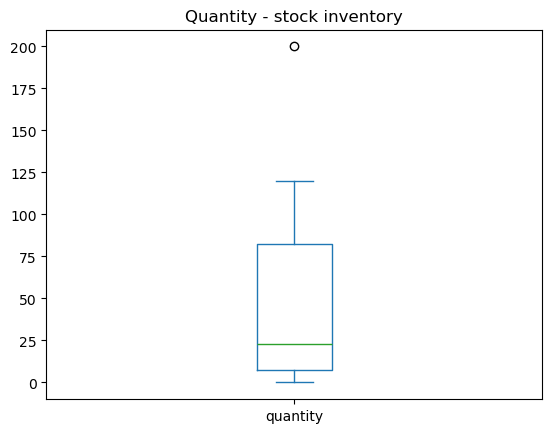

In [1]:
print(dummy_df['quantity'].describe())
dummy_df['quantity'].plot(kind='box')
plt.title('Quantity - stock inventory')
plt.show()
print('Interpretation: Most quantities are moderate, but 200 sits well above the rest and looks like a potential outlier.')

**Question on the lesson dataset - dirty_data.csv**

Use the `Duration` column in `df`. Run `describe()` on it, produce a boxplot for it, and print one sentence stating whether anything looks like a potential outlier.

## Concept 4 - Transform

Transform means changing the structure or content of the data to make it more useful. This includes renaming columns to cleaner names, changing a column's data type with `astype()`, and creating a new derived column from existing ones. Every transformation should have a reason. Do not transform for the sake of it.

In [1]:
dummy_df = dummy_df.rename(columns={'item': 'item_name'})
dummy_df['low_stock'] = dummy_df['quantity'] < 30
print(dummy_df.to_string(index=False))

item_name  quantity condition    supplier  low_stock
 Notebook     120.0      Good OfficeWorld      False
      Pen      45.0      Good     PaperCo      False
  Stapler       0.0   Damaged OfficeWorld       True
     Tape      23.0   Unknown     PaperCo       True
 Scissors       0.0   Damaged OfficeWorld       True
    Ruler      15.0      Good     PaperCo       True
     Clip     200.0      Good OfficeWorld      False


**Question on the lesson dataset - dirty_data.csv**

In `df`, rename at least one column to a cleaner name, change at least one column's type using `astype()`, create one new derived column from existing columns, and show the result.

## Concept 5 - Data Masking

Data masking means replacing or obscuring the actual values in a column so that sensitive or extreme values are hidden or categorised. A common use is to replace specific values with a label. Masking is not deletion. The row stays. The value is replaced.

In [1]:
dummy_df.loc[dummy_df['condition'] == 'Damaged', 'condition'] = 'flagged for review'
print(dummy_df.to_string(index=False))

item_name  quantity          condition    supplier  low_stock
 Notebook     120.0               Good OfficeWorld      False
      Pen      45.0               Good     PaperCo      False
  Stapler       0.0 flagged for review OfficeWorld       True
     Tape      23.0            Unknown     PaperCo       True
 Scissors       0.0 flagged for review OfficeWorld       True
    Ruler      15.0               Good     PaperCo       True
     Clip     200.0               Good OfficeWorld      False


**Question on the lesson dataset - dirty_data.csv**

Use the `Date` column in `df`. Identify one value that looks inconsistent or worth flagging, then use `.loc` to replace it with a review label of your choice. Show the rows that were changed.

## Concept 6 - Load

Load means saving the cleaned and transformed data to a new file. Never overwrite the original. Always save to a new filename. The new file should make clear that it is the cleaned version. Use `index=False` so the row numbers are not saved as a new column.

In [1]:
# Create a new cleaned output file from the dummy dataset.
# This file does not ship with the repo; you create it by running this step.
dummy_df.to_csv('/home/Phil/C&C/Learn_Python_Data/datasets/dummy_stock_clean.csv', index=False)
print('Saved learner-created file: dummy_stock_clean.csv')

Saved.


**Question on the lesson dataset - dirty_data.csv**

Save your cleaned `df` as a new output file called `dirty_data_clean.csv` using `index=False`, then print a confirmation message. This is a learner-created file produced by this exercise, not a starting file that comes with the repo.

## Concept 7 - Explain

Explain means writing a plain-English account of every decision you made during the ETL. For each column you touched, state what you found, what you did, and why. For anything you left unchanged, state why you left it. This is the most important step. A cleaned dataset with no explanation is not a deliverable. It is a mystery.

quantity - one missing value filled with 0. Zero is a reasonable default for stock count.

condition - one missing value filled with Unknown. Damaged values were later masked as flagged for review so the row stayed but the label changed.

supplier - one row dropped because the supplier was missing and that row could not be traced.

item_name - renamed from item for clarity.

low_stock - new derived column. Flags items with fewer than 30 units for reordering review.

**Question on the lesson dataset - dirty_data.csv**

Write your ETL explanation for `dirty_data.csv`. Cover every column you touched. State what you found, what you did, and why. Use a markdown cell, not a code cell.

## Run 2 - Timed ETL Drill on seattle_weather.csv

Set a 30-minute timer before you start this section. Stop when the timer expires whether you are finished or not. Incomplete is acceptable. Skipped is not.

Your task:
- Load `seattle_weather.csv` into `df2`
- Inspect: shape, types, missing values
- Handle any missing values with a documented decision
- Check one numeric column for outliers
- Apply at least one transformation
- Save the cleaned result as a new learner-created file called `seattle_weather_clean.csv`
- Write a plain-English ETL explanation covering every decision you made

No worked examples. No hints. No pre-filled cells.

## ETL Findings

1. Three plain-English observations from the `dirty_data` ETL


2. Three plain-English observations from the `seattle_weather` ETL


3. One sentence on the biggest difference between the two datasets as ETL targets


4. One sentence on anything that surprised you during either run